In [1]:
import pandas as pd
import feature_engineering_helper as hf
import pickle

In [2]:

### change this to 1 for quick test, 0 for full run
quick_test = 0
### change this to 1 for quick test, 0 for full run


if quick_test == 1:
    n_features_to_select=20
    step=20
    print("Quick test mode")
else:
    n_features_to_select=1
    step=5
    print("Full run mode")



Full run mode


In [3]:
data_prefix = '../data_curation/processed_data/'

if quick_test == 1:
    data_with_features = pd.read_parquet(data_prefix + 'data_with_all_features.parquet').head(300)
else:
    data_with_features = pd.read_parquet(data_prefix + 'data_with_all_features.parquet')
data_with_features.head()

,SMILES,MP,Type,RDKit_MaxAbsEStateIndex,RDKit_MaxEStateIndex,RDKit_MinAbsEStateIndex,RDKit_MinEStateIndex,RDKit_qed,RDKit_SPS,RDKit_MolWt,...,MACCS_157,MACCS_158,MACCS_159,MACCS_160,MACCS_161,MACCS_162,MACCS_163,MACCS_164,MACCS_165,MACCS_166
0,CCOC(=O)/C=C/C(=O)OCC,0.0,train_without_data_augmentation,10.634953,10.634953,0.297618,-0.536525,0.461644,9.833333,172.180,...,1,0,1,1,0,0,0,1,0,0
1,O=C(c1ccc(cc1)C(=O)Oc1cc(Cl)cc(c1)Cl)Oc1cc(Cl)...,230.0,train_without_data_augmentation,12.229922,12.229922,0.211872,-0.625117,0.322574,10.428571,456.108,...,1,0,1,0,0,1,1,1,1,0
2,O=C(c1ccccc1)Nc1cccc(c1)/N=N/c1cccc(c1)NC(=O)c...,285.0,train_without_data_augmentation,12.333151,12.333151,0.193012,-0.193012,0.344216,10.625000,420.472,...,0,1,1,0,1,1,1,1,1,0
3,C[SiH2]C,-150.0,train_without_data_augmentation,2.263889,2.263889,0.416667,0.416667,0.351522,6.000000,60.172,...,0,0,0,1,0,0,0,0,0,0
4,OCc1cccc(n1)CO,112.0,train_without_data_augmentation,8.613426,8.613426,0.075556,-0.075556,0.609080,9.800000,139.154,...,1,0,1,0,1,1,1,1,1,0


In [4]:
data_with_features['H?'] = data_with_features['MP'].apply(lambda x: 1 if x > 250 else 0)
data_with_features.head()

,SMILES,MP,Type,RDKit_MaxAbsEStateIndex,RDKit_MaxEStateIndex,RDKit_MinAbsEStateIndex,RDKit_MinEStateIndex,RDKit_qed,RDKit_SPS,RDKit_MolWt,...,MACCS_158,MACCS_159,MACCS_160,MACCS_161,MACCS_162,MACCS_163,MACCS_164,MACCS_165,MACCS_166,H?
0,CCOC(=O)/C=C/C(=O)OCC,0.0,train_without_data_augmentation,10.634953,10.634953,0.297618,-0.536525,0.461644,9.833333,172.180,...,0,1,1,0,0,0,1,0,0,0
1,O=C(c1ccc(cc1)C(=O)Oc1cc(Cl)cc(c1)Cl)Oc1cc(Cl)...,230.0,train_without_data_augmentation,12.229922,12.229922,0.211872,-0.625117,0.322574,10.428571,456.108,...,0,1,0,0,1,1,1,1,0,0
2,O=C(c1ccccc1)Nc1cccc(c1)/N=N/c1cccc(c1)NC(=O)c...,285.0,train_without_data_augmentation,12.333151,12.333151,0.193012,-0.193012,0.344216,10.625000,420.472,...,1,1,0,1,1,1,1,1,0,1
3,C[SiH2]C,-150.0,train_without_data_augmentation,2.263889,2.263889,0.416667,0.416667,0.351522,6.000000,60.172,...,0,0,1,0,0,0,0,0,0,0
4,OCc1cccc(n1)CO,112.0,train_without_data_augmentation,8.613426,8.613426,0.075556,-0.075556,0.609080,9.800000,139.154,...,0,1,0,1,1,1,1,1,0,0


In [5]:
def feature_engineering_workflow(data_type):

    # Extract all feature columns
    all_feature_cols = data_with_features.drop(columns=['SMILES', 'MP', 'Type', 'H?'], axis=1).columns.tolist()
    print(f"Total number of features: {len(all_feature_cols)}")

    # Subset data based on data_type
    if data_type == 'L':
        data = data_with_features[data_with_features['H?'] == 0].reset_index(drop=True)
    if data_type == 'H':
        data = data_with_features[data_with_features['H?'] == 1].reset_index(drop=True)
    print(f"Processing {data_type} dataset with shape: {data.shape}")
    print()

    # Standardize features
    df_X_scaled = hf.standardize_features(data = data, all_feature_cols=all_feature_cols, scaler_path= data_prefix + f'scaler_{data_type}.pkl', fit=True) 
    print()


    # Reduce features by variance threshold
    df_X_variance = hf.reduce_features_by_variance(df_X_scaled, variance_threshold=0.01)
    print()

    def RFE_workflow(df_X_variance, round):
        print()
        print(f'RFE feature selection: Round {round}:')
        # Reduce features by RFE
        RFE_results = hf.reduce_features_by_RFE(df_X_variance, data['MP'], n_features_to_select=n_features_to_select, step=step, metric='rmse', cv_strategy=None)
        print()

        # Plot RFE results
        hf.RFE_plot(RFE_results)

        # Pickle save the RFE_results
        with open(data_prefix + f'RFE_results_{data_type}_{round}.pkl', 'wb') as f:
            pickle.dump(RFE_results, f)

        df_X_RFE = df_X_variance[RFE_results['best_features']]

        return df_X_RFE, RFE_results

    # First round of RFE
    df_X_RFE, RFE_results_1 = RFE_workflow(df_X_variance, 1)

    # Feature binary interactions
    df_X_interaction = hf.feature_interaction(df_X_RFE)

    # Second round of RFE
    df_X_final, RFE_results_2 = RFE_workflow(df_X_interaction, 2)


    

    return df_X_scaled, df_X_variance, RFE_results_1, df_X_RFE, RFE_results_2, df_X_final

Total number of features: 384
Processing L dataset with shape: (16860, 388)

✓ Scaler saved to: ../data_curation/processed_data/scaler_L.pkl
✓ Standardization complete. Shape: (16860, 384)

Original features: 384
Removed features: 14
Remaining features: 370


RFE feature selection: Round 1:


RFE Feature Selection:   1%|▏         | 1/74 iteration

Iteration 0/74 | Features: 365 | RMSE: 35.0672 ± 0.6874 | Removed: [RDKit_fr_phos_ester, RDKit_fr_piperzine, RDKit_fr_term_acetylene, RDKit_fr_tetrazole, MACCS_33]


RFE Feature Selection:  15%|█▍        | 11/74 iteration

Iteration 10/74 | Features: 315 | RMSE: 35.1117 ± 0.7823 | Removed: [RDKit_EState_VSA11, RDKit_NumAromaticRings, RDKit_NumSaturatedRings, RDKit_fr_Nhpyrrole, MACCS_130]


...

Iteration 60/74 | Features: 65 | RMSE: 36.3071 ± 0.7173 | Removed: [RDKit_BCUT2D_MRHI, RDKit_SMR_VSA4, RDKit_fr_Al_OH, RDKit_fr_Ar_NH, MACCS_47]


RFE Feature Selection:  96%|█████████▌| 71/74 iteration

Iteration 70/74 | Features: 15 | RMSE: 41.5933 ± 0.8826 | Removed: [RDKit_SMR_VSA10, RDKit_fr_COO, RDKit_fr_NH0, RDKit_fr_isocyan, RDKit_fr_quatN]


RFE Feature Selection: 100%|██████████| 74/74 iteration


Global best RMSE: 34.8278
Threshold (5% tolerance): 36.5691

✓ RFE Feature Selection Complete (Parsimonious)
  Selected number of features: 60
  Selected RMSE: 36.5110
  Best features: ['RDKit_BertzCT', 'RDKit_Chi3v', 'RDKit_LabuteASA', 'RDKit_PEOE_VSA14', 'RDKit_SMR_VSA10']...



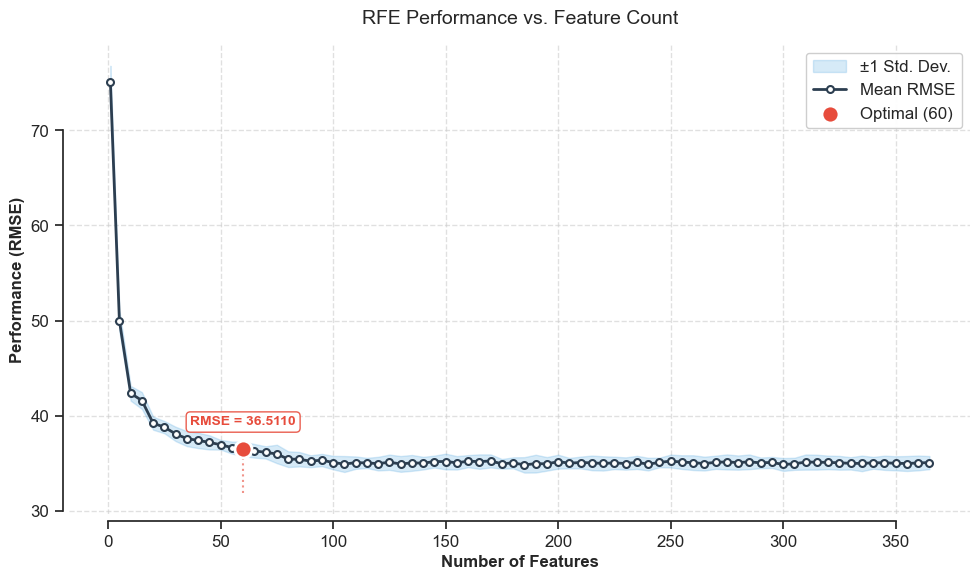

  Optimal Feature Set: 60 features
  Best RMSE: 36.5110
Generating 1770 interaction features from 60 original features...

RFE feature selection: Round 2:


RFE Feature Selection:   0%|          | 1/366 iteration

Iteration 0/366 | Features: 1825 | RMSE: 36.4416 ± 0.6549 | Removed: [RDKit_TPSA X MACCS_105, RDKit_fr_ether X RDKit_fr_furan, RDKit_fr_ether X RDKit_fr_isocyan, RDKit_fr_ether X RDKit_fr_quatN, MACCS_161 X MACCS_163]


RFE Feature Selection:   3%|▎         | 11/366 iteration

Iteration 10/366 | Features: 1775 | RMSE: 36.4313 ± 0.7256 | Removed: [RDKit_SlogP_VSA7 X MACCS_163, RDKit_fr_ether X MACCS_43, RDKit_fr_ether X MACCS_101, RDKit_fr_ether X MACCS_109, MACCS_126 X MACCS_161]


...

Iteration 350/366 | Features: 75 | RMSE: 37.0633 ± 0.7885 | Removed: [RDKit_LabuteASA X RDKit_NumHeteroatoms, RDKit_SMR_VSA10 X RDKit_TPSA, RDKit_SMR_VSA10 X RDKit_RingCount, RDKit_SlogP_VSA1 X RDKit_fr_sulfone, RDKit_NumHeterocycles X RDKit_fr_unbrch_alkane]


RFE Feature Selection:  99%|█████████▊| 361/366 iteration

Iteration 360/366 | Features: 25 | RMSE: 39.3920 ± 0.5377 | Removed: [RDKit_BertzCT X RDKit_NHOHCount, RDKit_BertzCT X MACCS_43, RDKit_SMR_VSA10 X RDKit_fr_quatN, RDKit_TPSA X RDKit_NumHDonors, RDKit_NumRotatableBonds X RDKit_fr_quatN]


RFE Feature Selection: 100%|██████████| 366/366 iteration


Global best RMSE: 36.2057
Threshold (5% tolerance): 38.0160

✓ RFE Feature Selection Complete (Parsimonious)
  Selected number of features: 45
  Selected RMSE: 37.9232
  Best features: ['RDKit_BertzCT', 'RDKit_NumHDonors', 'RDKit_RingCount', 'RDKit_BertzCT X RDKit_NHOHCount', 'RDKit_BertzCT X RDKit_NumHDonors']...



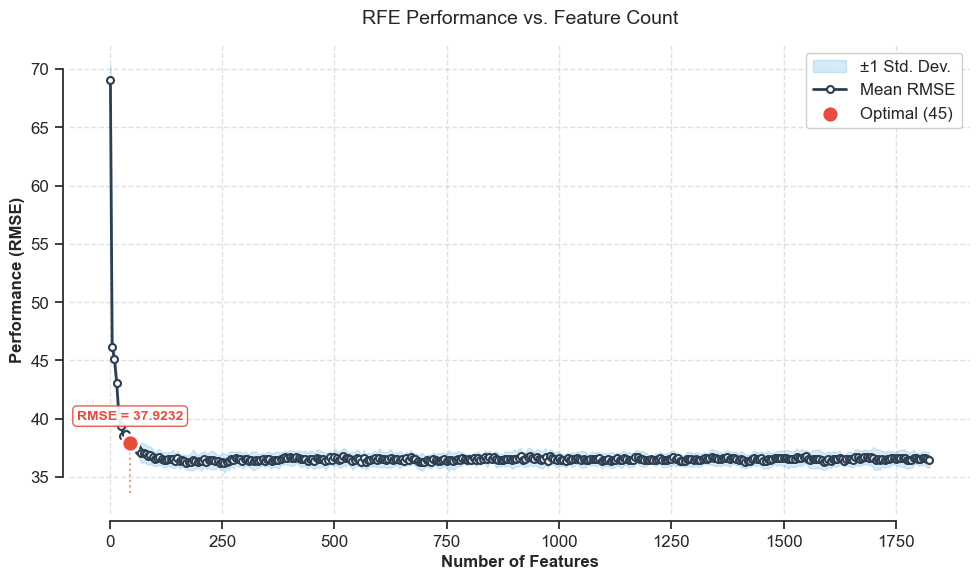

  Optimal Feature Set: 45 features
  Best RMSE: 37.9232


In [6]:
df_L_X_scaled, df_L_X_variance, RFE_results_L_1, df_L_X_RFE, RFE_results_L_2, df_L_X_final = feature_engineering_workflow('L')

Total number of features: 384
Processing H dataset with shape: (773, 388)

✓ Scaler saved to: ../data_curation/processed_data/scaler_H.pkl
✓ Standardization complete. Shape: (773, 384)

Original features: 384
Removed features: 30
Remaining features: 354


RFE feature selection: Round 1:


RFE Feature Selection:   1%|▏         | 1/71 iteration

Iteration 0/71 | Features: 349 | RMSE: 29.2691 ± 2.8994 | Removed: [RDKit_fr_morpholine, MACCS_18, MACCS_19, MACCS_20, MACCS_21]


RFE Feature Selection:  15%|█▌        | 11/71 iteration

Iteration 10/71 | Features: 299 | RMSE: 29.4078 ± 2.9378 | Removed: [RDKit_RingCount, MACCS_80, MACCS_81, MACCS_82, MACCS_164]


...

Iteration 50/71 | Features: 99 | RMSE: 28.3036 ± 2.5447 | Removed: [RDKit_FpDensityMorgan1, RDKit_Chi2n, RDKit_PEOE_VSA10, RDKit_SMR_VSA7, RDKit_SlogP_VSA3]


RFE Feature Selection:  86%|████████▌ | 61/71 iteration

Iteration 60/71 | Features: 49 | RMSE: 28.3978 ± 3.2935 | Removed: [RDKit_MaxAbsPartialCharge, RDKit_BCUT2D_MWLOW, RDKit_PEOE_VSA13, RDKit_NumAmideBonds, MACCS_48]


RFE Feature Selection: 100%|██████████| 71/71 iteration

Iteration 70/71 | Features: 1 | RMSE: 30.1504 ± 4.6453 | Removed: [RDKit_SlogP_VSA8, RDKit_fr_aniline, RDKit_fr_nitrile]

Global best RMSE: 27.1359
Threshold (5% tolerance): 28.4927

✓ RFE Feature Selection Complete (Parsimonious)
  Selected number of features: 34
  Selected RMSE: 28.3928
  Best features: ['RDKit_FpDensityMorgan3', 'RDKit_BCUT2D_CHGLO', 'RDKit_Chi0v', 'RDKit_Chi2v', 'RDKit_Chi4v']...



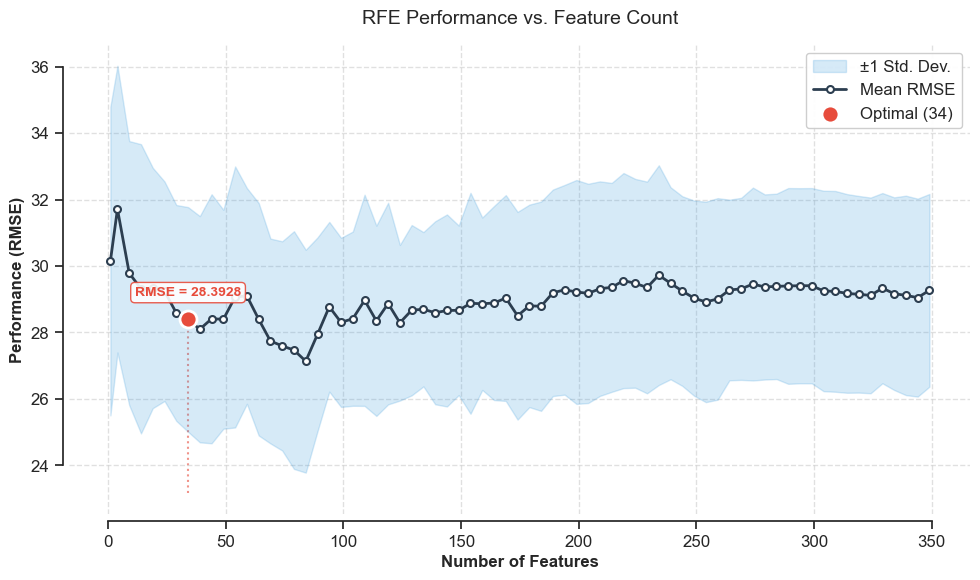

  Optimal Feature Set: 34 features
  Best RMSE: 28.3928
Generating 561 interaction features from 34 original features...

RFE feature selection: Round 2:


RFE Feature Selection:   1%|          | 1/119 iteration

Iteration 0/119 | Features: 590 | RMSE: 28.9264 ± 4.4714 | Removed: [RDKit_SMR_VSA3 X MACCS_39, RDKit_EState_VSA5 X RDKit_fr_bicyclic, RDKit_EState_VSA5 X RDKit_fr_nitrile, RDKit_NumHeterocycles X RDKit_fr_aniline, MACCS_138 X MACCS_144]


RFE Feature Selection:   9%|▉         | 11/119 iteration

Iteration 10/119 | Features: 540 | RMSE: 29.2080 ± 3.9625 | Removed: [RDKit_PEOE_VSA11 X RDKit_fr_nitrile, RDKit_PEOE_VSA11 X MACCS_39, RDKit_SMR_VSA10 X RDKit_NumRotatableBonds, RDKit_SlogP_VSA11 X RDKit_fr_nitrile, RDKit_fr_nitrile X MACCS_39]


...

Iteration 100/119 | Features: 90 | RMSE: 27.0578 ± 3.8722 | Removed: [RDKit_FpDensityMorgan3 X RDKit_SMR_VSA10, RDKit_FpDensityMorgan3 X RDKit_fr_COO, RDKit_Chi4v X MACCS_144, RDKit_SlogP_VSA2 X RDKit_SlogP_VSA8, RDKit_SlogP_VSA8 X RDKit_EState_VSA3]


RFE Feature Selection:  93%|█████████▎| 111/119 iteration

Iteration 110/119 | Features: 40 | RMSE: 26.8430 ± 4.6557 | Removed: [RDKit_FpDensityMorgan3 X RDKit_PEOE_VSA6, RDKit_BCUT2D_CHGLO X RDKit_PEOE_VSA8, RDKit_Chi4v X RDKit_fr_bicyclic, RDKit_VSA_EState1 X RDKit_fr_allylic_oxid, RDKit_NumRotatableBonds X RDKit_fr_allylic_oxid]


RFE Feature Selection: 100%|██████████| 119/119 iteration


Global best RMSE: 25.4550
Threshold (5% tolerance): 26.7277

✓ RFE Feature Selection Complete (Parsimonious)
  Selected number of features: 35
  Selected RMSE: 26.1752
  Best features: ['RDKit_FpDensityMorgan3 X MACCS_39', 'RDKit_BCUT2D_CHGLO X RDKit_PEOE_VSA6', 'RDKit_BCUT2D_CHGLO X RDKit_SlogP_VSA12', 'RDKit_BCUT2D_CHGLO X RDKit_SlogP_VSA5', 'RDKit_BCUT2D_CHGLO X MACCS_39']...



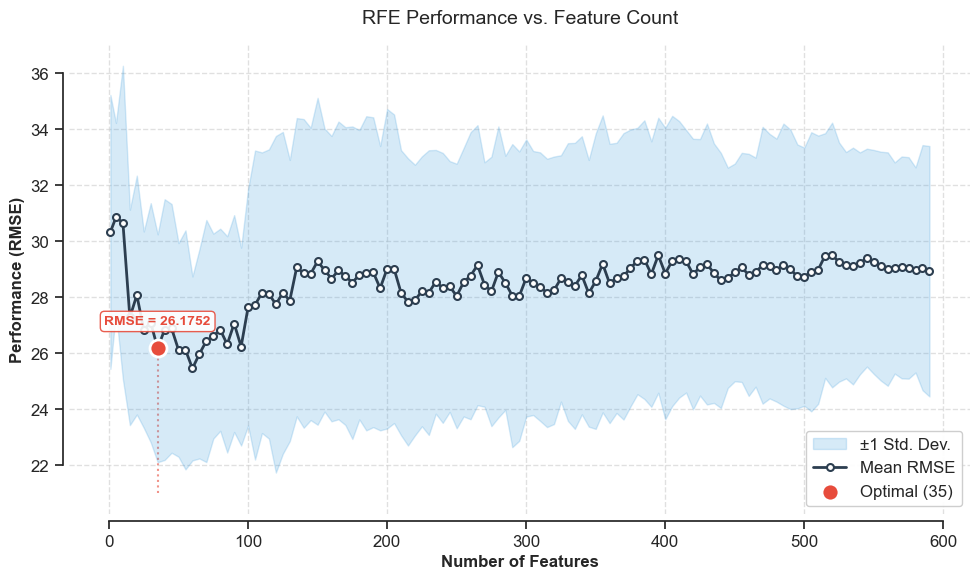

  Optimal Feature Set: 35 features
  Best RMSE: 26.1752


In [7]:
df_H_X_scaled, df_H_X_variance, RFE_results_H_1, df_H_X_RFE, RFE_results_H_2, df_H_X_final = feature_engineering_workflow('H')

In [8]:
def combine_features(df_L_X_final, df_H_X_final):

    # Number of features in each set
    n_features_L = df_L_X_final.shape[1]
    n_features_H = df_H_X_final.shape[1]
    print(f"Number of features in L dataset: {n_features_L}")
    print(f"Number of features in H dataset: {n_features_H}")

    # Number of overlapping features
    overlapping_features = set(df_L_X_final.columns).intersection(set(df_H_X_final.columns))
    n_overlapping_features = len(overlapping_features)
    print(f"Number of overlapping features: {n_overlapping_features}")
    print(f"Overlapping features: {overlapping_features}")

    # Combine features
    combined_features = list(set(df_L_X_final.columns).union(set(df_H_X_final.columns)))
    print(f"Total number of combined features: {len(combined_features)}")

    return combined_features

In [9]:
selected_features = combine_features(df_L_X_final, df_H_X_final)

Number of features in L dataset: 45
Number of features in H dataset: 35
Number of overlapping features: 0
Overlapping features: set()
Total number of combined features: 80


In [16]:
with open(data_prefix + 'selected_feature_list.pkl', 'wb') as f:
    pickle.dump(selected_features, f)

In [18]:
with open(data_prefix + 'selected_feature_list.pkl', 'rb') as f:
    selected_features  = pickle.load(f)

print(selected_features)
print(len(selected_features))

['RDKit_NumRotatableBonds X RDKit_fr_quatN', 'RDKit_BCUT2D_CHGLO X RDKit_SlogP_VSA5', 'RDKit_SlogP_VSA8 X RDKit_fr_bicyclic', 'RDKit_TPSA X RDKit_NumHDonors', 'MACCS_156 X MACCS_163', 'RDKit_SMR_VSA5 X MACCS_39', 'RDKit_Chi0v X MACCS_144', 'RDKit_fr_NH1 X RDKit_fr_SH', 'RDKit_Kappa1 X RDKit_SlogP_VSA2', 'MACCS_126 X MACCS_127', 'RDKit_LabuteASA X RDKit_TPSA', 'RDKit_TPSA X RDKit_MolMR', 'RDKit_BCUT2D_CHGLO X MACCS_39', 'RDKit_fr_isocyan X MACCS_114', 'RDKit_TPSA X RDKit_RingCount', 'RDKit_BCUT2D_CHGLO X RDKit_PEOE_VSA6', 'RDKit_fr_Ar_COO X RDKit_fr_bicyclic', 'RDKit_SlogP_VSA12 X RDKit_SlogP_VSA8', 'RDKit_PEOE_VSA14 X RDKit_fr_unbrch_alkane', 'RDKit_TPSA X RDKit_NHOHCount', 'RDKit_SlogP_VSA5 X RDKit_fr_bicyclic', 'RDKit_EState_VSA5 X RDKit_fr_aniline', 'RDKit_BertzCT', 'RDKit_NumHDonors', 'RDKit_SMR_VSA10 X MACCS_138', 'RDKit_fr_COO X RDKit_fr_bicyclic', 'RDKit_TPSA X RDKit_fr_SH', 'RDKit_RingCount X RDKit_fr_COO', 'RDKit_PEOE_VSA6 X RDKit_fr_nitrile', 'RDKit_PEOE_VSA14 X RDKit_RingCou

# Example showing how to get a dataset with the selected features

In [21]:
data_with_all_features = pd.read_parquet(data_prefix + 'data_with_all_features.parquet')

In [22]:
data_with_selected_features = hf.dataset_featurization(data_with_all_features, selected_features, data_prefix + 'data_with_selected_feaatures')
data_with_selected_features

/Users/sdl5_mp/Documents/GitHub/melting_point_2026/feature_engineering/feature_engineering_helper.py:43: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data_with_features[f'RDKit_{name}'] = [f[i] for f in rdkit_features]
/Users/sdl5_mp/Documents/GitHub/melting_point_2026/feature_engineering/feature_engineering_helper.py:43: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data_with_features[f'RDKit_{name}'] = [f[i] for f in rdkit_features]
/Users/sdl5_mp/Documents/GitHub/melting_point_2026/feature_engineering/feature_engineering_hel

✓ RDKit: Added 217 features


/Users/sdl5_mp/Documents/GitHub/melting_point_2026/feature_engineering/feature_engineering_helper.py:65: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data_with_features[f'MACCS_{i}'] = maccs_array[:, i]
/Users/sdl5_mp/Documents/GitHub/melting_point_2026/feature_engineering/feature_engineering_helper.py:65: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data_with_features[f'MACCS_{i}'] = maccs_array[:, i]
/Users/sdl5_mp/Documents/GitHub/melting_point_2026/feature_engineering/feature_engineering_helper.py:65: PerformanceWarning: D

✓ MACCS: Added 167 features
Generating 73536 interaction features from 384 original features...
../data_curation/processed_data/data_with_selected_feaatures dataset saved.


,SMILES,MP,Type,RDKit_NumRotatableBonds X RDKit_fr_quatN,RDKit_BCUT2D_CHGLO X RDKit_SlogP_VSA5,RDKit_SlogP_VSA8 X RDKit_fr_bicyclic,RDKit_TPSA X RDKit_NumHDonors,MACCS_156 X MACCS_163,RDKit_SMR_VSA5 X MACCS_39,RDKit_Chi0v X MACCS_144,...,RDKit_fr_aniline X MACCS_39,RDKit_fr_Ar_COO X MACCS_43,RDKit_PEOE_VSA11 X RDKit_NumRotatableBonds,RDKit_SlogP_VSA8 X RDKit_NumRotatableBonds,RDKit_NumHeteroatoms X RDKit_RingCount,RDKit_TPSA X RDKit_fr_azide,RDKit_SMR_VSA3 X RDKit_fr_allylic_oxid,RDKit_fr_isocyan X MACCS_155,MACCS_43 X MACCS_101,RDKit_HallKierAlpha X RDKit_NumRotatableBonds
0,CCOC(=O)/C=C/C(=O)OCC,0.0,train_without_data_augmentation,0,-27.008421,0.0,0.00,0,0.0,0.0,...,0,0,0.000000,0.0,0,0.0,0.0,0,0,-5.28
1,O=C(c1ccc(cc1)C(=O)Oc1cc(Cl)cc(c1)Cl)Oc1cc(Cl)...,230.0,train_without_data_augmentation,0,-42.952915,0.0,0.00,0,0.0,0.0,...,0,0,0.000000,0.0,24,0.0,0.0,0,0,-8.96
2,O=C(c1ccccc1)Nc1cccc(c1)/N=N/c1cccc(c1)NC(=O)c...,285.0,train_without_data_augmentation,0,-42.684060,0.0,165.84,1,0.0,0.0,...,0,0,0.000000,0.0,24,0.0,0.0,0,0,-27.48
3,C[SiH2]C,-150.0,train_without_data_augmentation,0,-0.000000,0.0,0.00,0,0.0,0.0,...,0,0,0.000000,0.0,0,0.0,0.0,0,0,0.00
4,OCc1cccc(n1)CO,112.0,train_without_data_augmentation,0,-22.352189,0.0,106.70,1,0.0,0.0,...,0,0,0.000000,0.0,3,0.0,0.0,0,0,-1.86
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17628,[O-][N+](=O)CCO,-80.0,train_without_data_augmentation,0,-0.000000,0.0,63.37,0,0.0,0.0,...,0,0,0.000000,0.0,0,0.0,0.0,0,0,-1.28
17629,N#CCc1ccc(cc1)OC(=O)C,50.0,train_without_data_augmentation,0,-24.987886,0.0,0.00,0,0.0,0.0,...,0,0,0.000000,0.0,3,0.0,0.0,0,0,-3.64
17630,CCOC(=O)/C(=N\Nc1ccc(cc1)[N+](=O)[O-])/C(=O)C(...,184.0,train_without_data_augmentation,0,-14.407546,0.0,110.90,1,0.0,0.0,...,0,0,0.000000,0.0,11,0.0,0.0,0,0,-17.88
17631,O/N=C/1\C(=O)N(N=C1c1ccc(cc1)[N+](=O)[O-])c1cc...,223.0,train_without_data_augmentation,0,-11.652017,0.0,108.40,1,0.0,0.0,...,0,0,17.135055,0.0,24,0.0,0.0,0,0,-10.65


In [23]:
data_with_selected_features.describe()

,MP,RDKit_NumRotatableBonds X RDKit_fr_quatN,RDKit_BCUT2D_CHGLO X RDKit_SlogP_VSA5,RDKit_SlogP_VSA8 X RDKit_fr_bicyclic,RDKit_TPSA X RDKit_NumHDonors,MACCS_156 X MACCS_163,RDKit_SMR_VSA5 X MACCS_39,RDKit_Chi0v X MACCS_144,RDKit_fr_NH1 X RDKit_fr_SH,RDKit_Kappa1 X RDKit_SlogP_VSA2,...,RDKit_fr_aniline X MACCS_39,RDKit_fr_Ar_COO X MACCS_43,RDKit_PEOE_VSA11 X RDKit_NumRotatableBonds,RDKit_SlogP_VSA8 X RDKit_NumRotatableBonds,RDKit_NumHeteroatoms X RDKit_RingCount,RDKit_TPSA X RDKit_fr_azide,RDKit_SMR_VSA3 X RDKit_fr_allylic_oxid,RDKit_fr_isocyan X MACCS_155,MACCS_43 X MACCS_101,RDKit_HallKierAlpha X RDKit_NumRotatableBonds
count,17633.000000,17633.000000,17630.000000,17633.000000,17633.000000,17633.000000,17633.000000,17633.000000,17633.000000,17633.000000,...,17633.000000,17633.000000,17633.000000,17633.000000,17633.000000,17633.000000,17633.000000,17633.000000,17633.000000,17633.000000
mean,103.612448,0.013441,-45.334936,3.528943,65.272247,0.427097,0.071649,4.087613,0.001078,256.310205,...,0.000624,0.000454,8.254568,6.793127,7.768446,0.040388,0.219181,0.000681,0.005444,-4.658544
std,91.086643,0.595078,57.083860,16.252614,230.050242,0.494671,1.518237,5.683607,0.036101,504.507866,...,0.031045,0.021296,36.437735,21.675176,10.621429,2.083051,2.247690,0.031944,0.073587,8.324745
min,-205.000000,0.000000,-717.415312,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.383171,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-380.940000
25%,47.000000,0.000000,-58.110070,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,54.821838,...,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,-6.090000
50%,106.000000,0.000000,-26.071678,0.000000,23.470000,0.000000,0.000000,0.000000,0.000000,135.100443,...,0.000000,0.000000,0.000000,0.000000,4.000000,0.000000,0.000000,0.000000,0.000000,-2.140000
75%,167.000000,0.000000,-10.982733,0.000000,72.830000,1.000000,0.000000,7.954905,0.000000,289.408150,...,0.000000,0.000000,0.000000,0.000000,10.000000,0.000000,0.000000,0.000000,0.000000,-0.160000
max,517.000000,48.000000,-0.000000,485.934468,19449.500000,1.000000,82.448259,59.894417,2.000000,19043.298491,...,2.000000,1.000000,3274.860301,689.436699,506.000000,161.460000,95.702195,2.000000,1.000000,37.920000
